In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
sns.set(style = "whitegrid")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)

/tmp/ipykernel_20527/265101205.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)


In [5]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1:'Yes', 0:'No'})

#### EDA

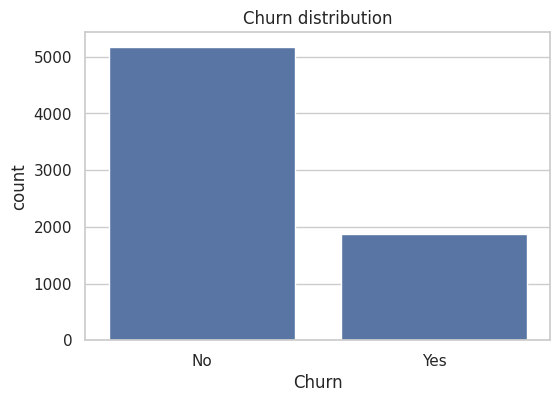

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4)),
sns.countplot(x='Churn', data = df),
plt.title('Churn distribution')
plt.show()

In [7]:
def eda_plot(df):
    for col in df.columns:
         if pd.api.types.is_numeric_dtype(df[col]):
             plt.figure(figsize=(8,4)),
             sns.boxplot(x = df[col], y ="Churn", data = df),
             plt.title(f"Churn vs {col}"),
             plt.show()
         else:
             plt.figure(figsize=(8,4)),
             sns.countplot(x = df[col], hue = "Churn", data=df),
             plt.title(f"Churn vs {col}"),
             plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


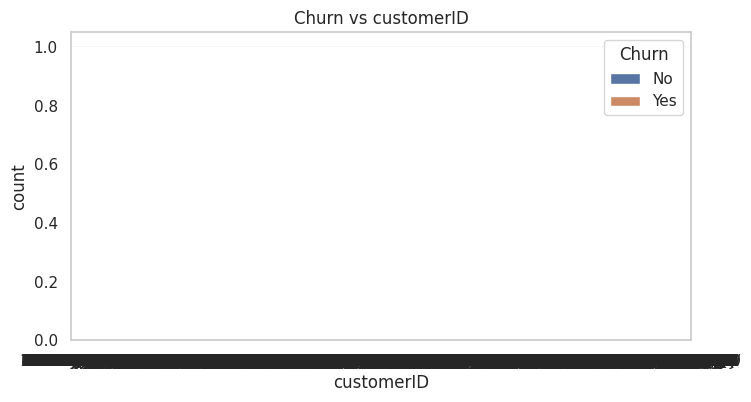

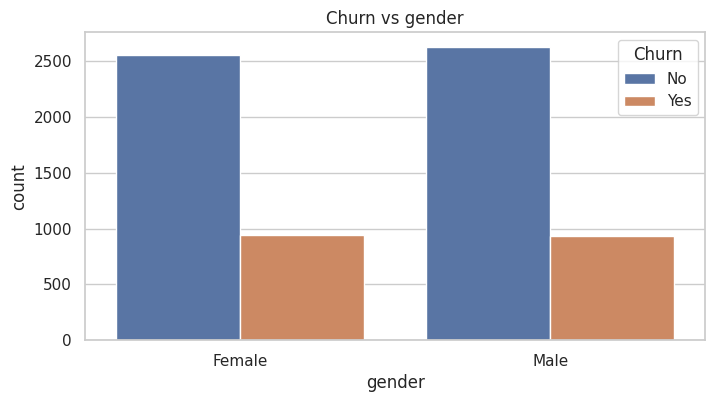

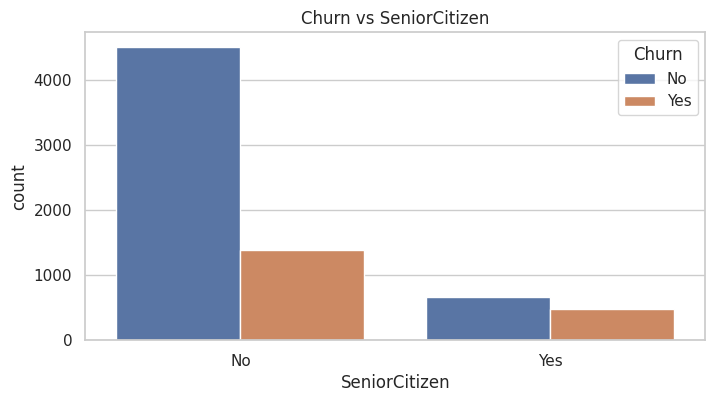

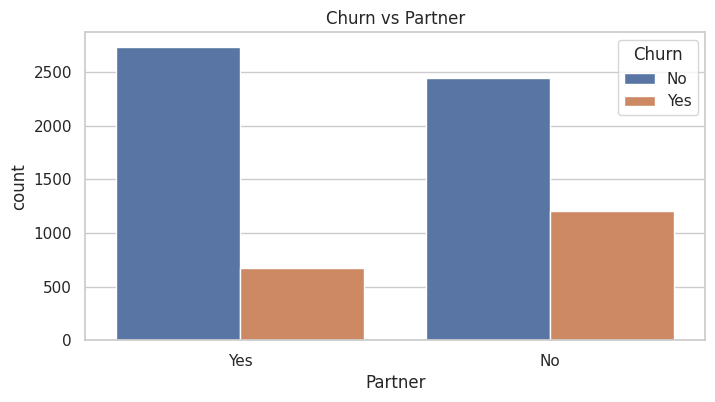

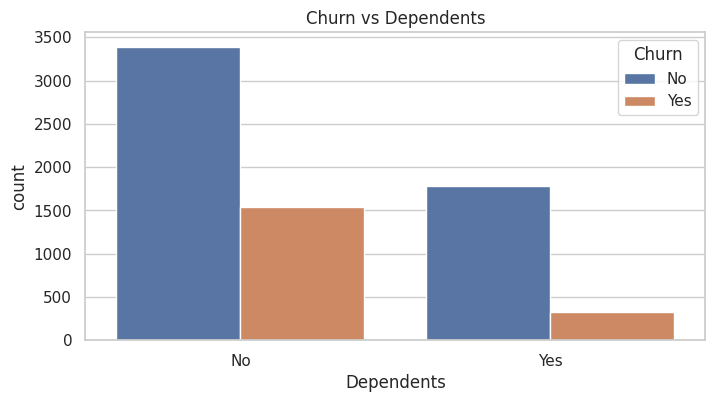

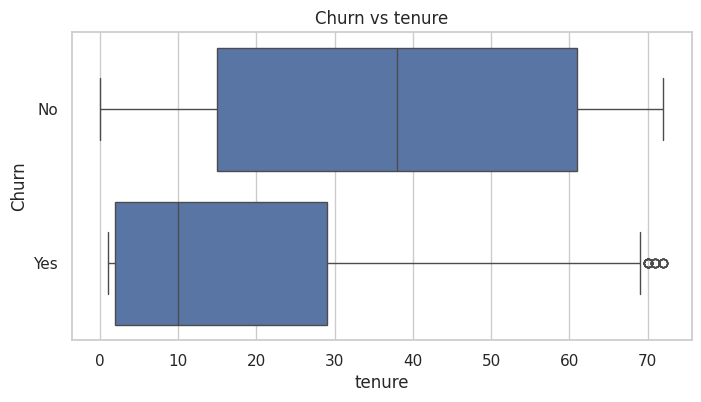

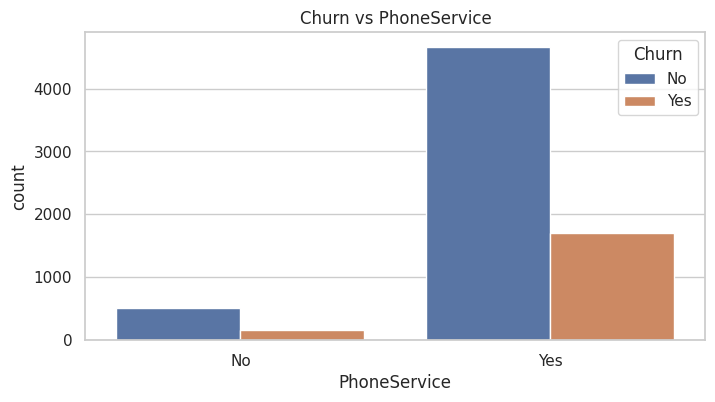

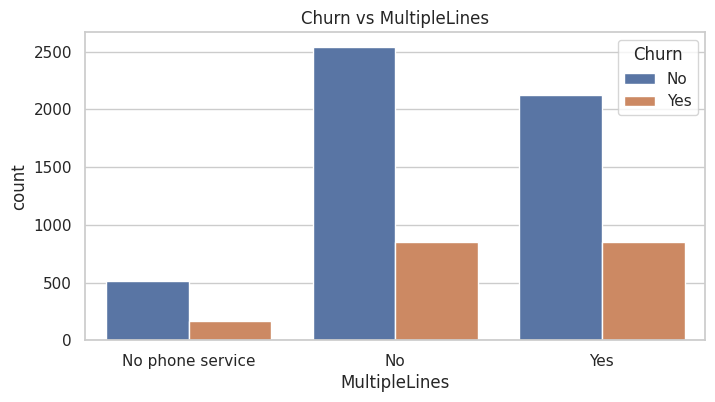

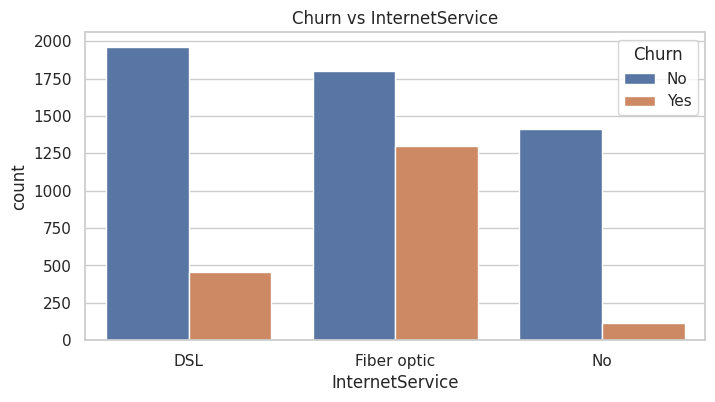

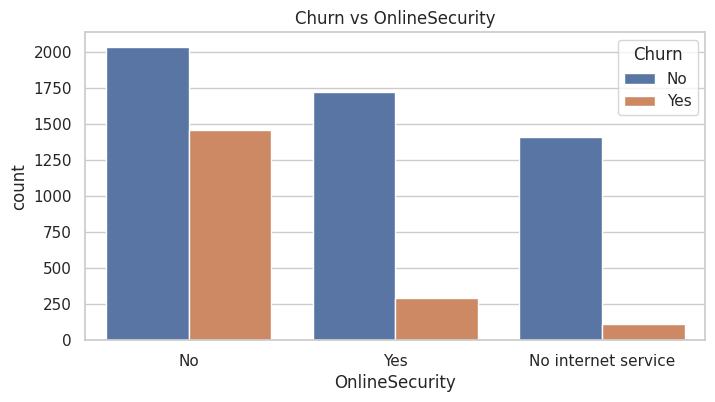

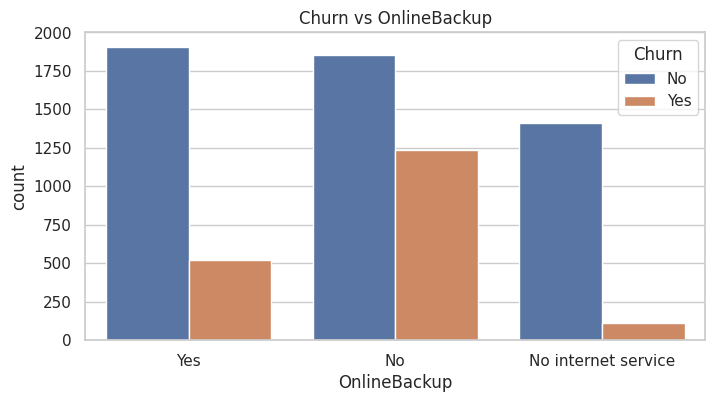

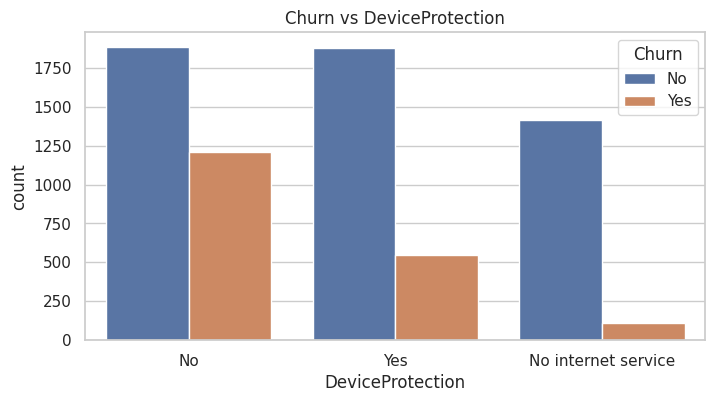

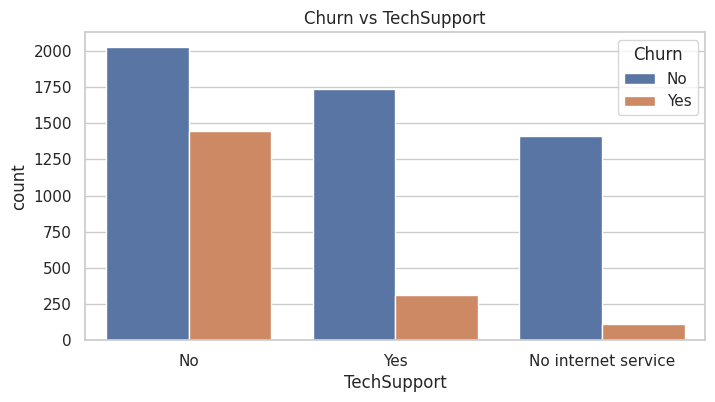

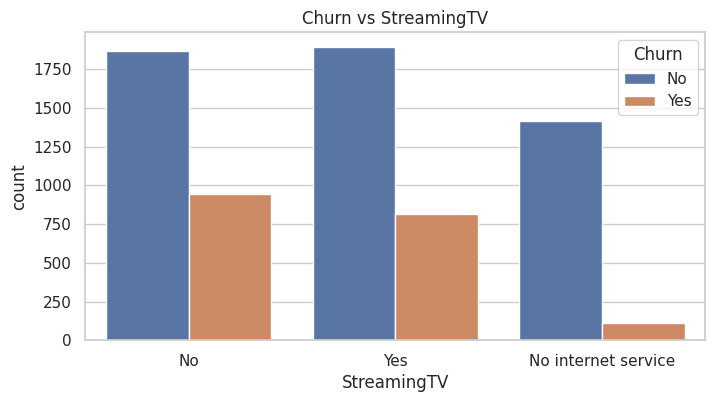

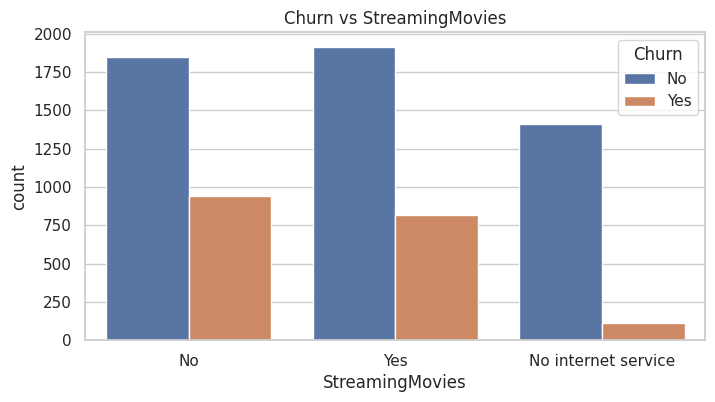

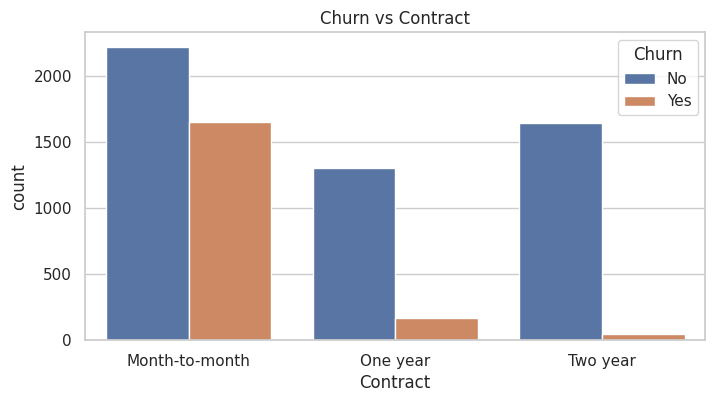

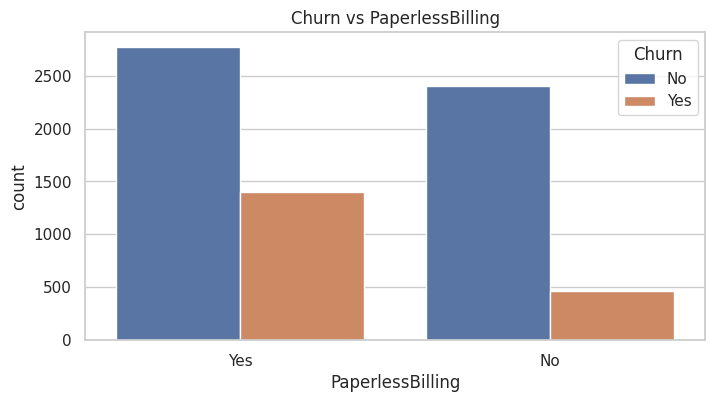

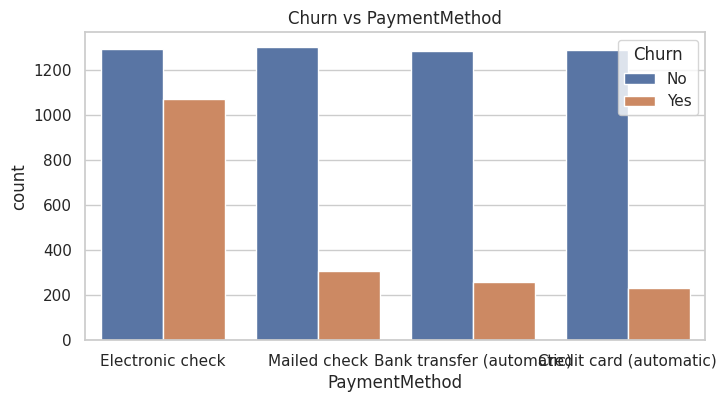

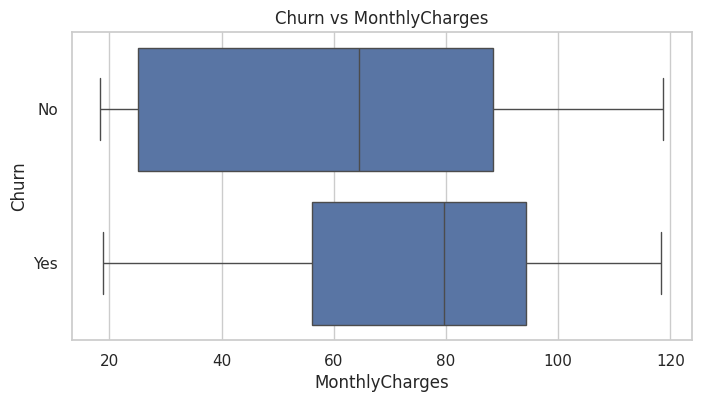

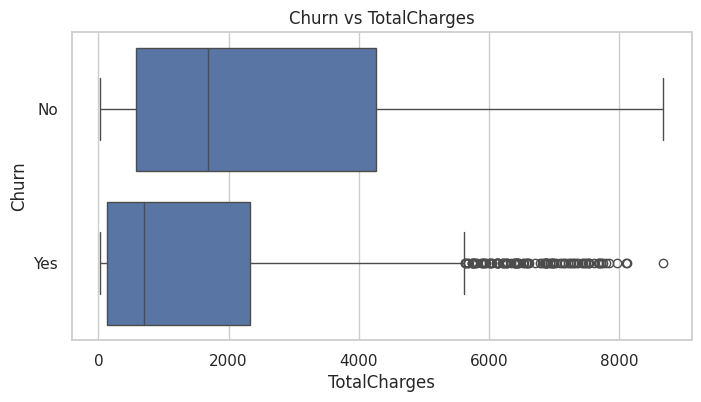

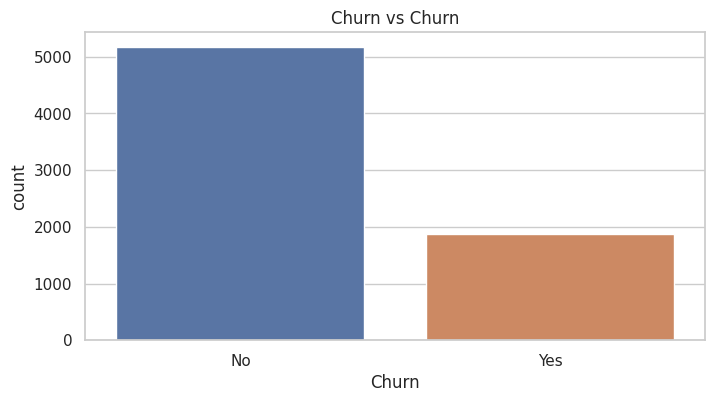

In [8]:
eda_plot(df)

#### Pre processing

In [9]:
df['TenureGroup'] = df['tenure'].apply(lambda x: 'Long term' if x > 12 else 'Short term')

In [10]:
df['Family'] = df.apply(
    lambda row: 'No' if (row['Dependents'] == 'No' and row['Partner'] == 'No') else 'Yes',
    axis=1
)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'Family'],
      dtype='object')

In [12]:
df.drop(columns=['customerID', 'Partner', 'Dependents', 'tenure'], inplace=True) #drop costomerID as it is redundant

In [13]:
df.describe(include='object')

,gender,SeniorCitizen,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,TenureGroup,Family
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2,2,2
top,Male,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Long term,Yes
freq,3555,5901,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174,4857,3763


In [14]:
df.columns

Index(['gender', 'SeniorCitizen', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'TenureGroup', 'Family'],
      dtype='object')

In [15]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [16]:
X = df.drop("Churn", axis=1) #select dependent features
y = df["Churn"]             #select target feature

In [17]:
X_num = df[['MonthlyCharges', 'TotalCharges']]
X_binary = pd.get_dummies(df[['gender', 'Family', 'PhoneService', 'PaperlessBilling', 'TenureGroup', 'SeniorCitizen']], drop_first=True, dtype=int)
X_rest = pd.get_dummies(df[['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
         'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']], dtype=int)
X_final = pd.concat([X_binary, X_rest, X_num], axis=1)

In [18]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)
X_tr_res, y_tr_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_tr_res.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV    #initialize random search cv to find best parameters
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
param_dist = {
    'n_estimators': np.arange(100,501,50),      #number of boosting rounds
    'max_depth': np.arange(3,11),               #depth of tree
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    #step size for learning tree
    'sub_sample': [0.6, 0.8, 1],                #row sampling
    'colsample_bytree': [0.6, 0.8, 1],          #feature sampling
    'gamma': [0, 0.1, 0.2, 0.5],                #min loss reduction
    'reg_alpha': [0, 0.01, 0.1, 1],             #L1 regularization
    'reg_lambda': [0.1, 1, 10]                  #L2 regularization
}
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                                  # number of random combinations
    cv=3,                                       #number of folds
    scoring='roc_auc',
    n_jobs= -1,
    random_state=42
)
random_search_xgb.fit(X_tr_res, y_tr_res)
print("Best parameters:", random_search_xgb.best_params_)
print("ROC_AUC Score:", random_search_xgb.best_score_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:39:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'sub_sample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': np.int64(250), 'max_depth': np.int64(4), 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
ROC_AUC Score: 0.9351780815512308


In [20]:
best_params = random_search_xgb.best_params_
best_xgb = XGBClassifier(
    use_label_encoder=False,                       #fit the data to XGB classifier with best parameters and predict test data
    eval_metric = 'logloss',
    random_state=42,
    **best_params
)
best_xgb.fit(X_tr_res, y_tr_res)
y_pred = best_xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:39:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
print(roc_auc_score(y_test, y_pred))

0.730866206825286


In [22]:
print(confusion_matrix(y_test, y_pred))

[[893 142]
 [150 224]]


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.60      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [24]:
y_proba = best_xgb.predict_proba(X_test)[:,1]
y_pred_new = (y_proba>=0.4).astype(int)
print(roc_auc_score(y_test,y_pred_new))
print(confusion_matrix(y_test,y_pred_new))
print(classification_report(y_test,y_pred_new))

0.7422459893048129
[[828 207]
 [118 256]]
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



In [25]:
feature_importance = pd.DataFrame({"Features": X_final.columns,
                                   "importance": best_xgb.feature_importances_})
feature_importance = feature_importance.sort_values( by = "importance", ascending=False)
print(feature_importance)

                                   Features  importance
31                        Contract_One year    0.152818
30                  Contract_Month-to-month    0.149837
32                        Contract_Two year    0.142844
11                       InternetService_No    0.049449
14                       OnlineSecurity_Yes    0.043762
10              InternetService_Fiber optic    0.035785
34    PaymentMethod_Credit card (automatic)    0.034795
23                          TechSupport_Yes    0.034343
13       OnlineSecurity_No internet service    0.033292
7            MultipleLines_No phone service    0.027984
12                        OnlineSecurity_No    0.027731
36               PaymentMethod_Mailed check    0.024169
33  PaymentMethod_Bank transfer (automatic)    0.022966
4                    TenureGroup_Short term    0.021952
1                                Family_Yes    0.020236
17                         OnlineBackup_Yes    0.019172
21                           TechSupport_No    0

#### Decile

In [26]:
y_pred_proba = best_xgb.predict_proba(X_test)[:,1]  # probability of positive class

# Put them into a dataframe
df_scores = pd.DataFrame({
    'actual': y_test,
    'predicted_score': y_pred_proba
})

bins = np.arange(0, 1.1, 0.1)   # step of 0.1
labels = [f"{int(left*100)}-{int(right*100)}" for left, right in zip(bins[:-1], bins[1:])]

df_scores['proba_band'] = pd.cut(df_scores['predicted_score'], bins=bins, labels=labels, include_lowest=True)

# Count how many data points fall in each band
band_counts = df_scores['proba_band'].value_counts().sort_index()

print(band_counts)

proba_band
0-10      549
10-20     171
20-30     124
30-40     102
40-50      97
50-60      89
60-70     104
70-80      81
80-90      60
90-100     32
Name: count, dtype: int64


#### Backward Probability

In [27]:
X_new = X_final[['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'OnlineSecurity_No internet service',
                 'InternetService_No', 'MultipleLines_No phone service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'PhoneService_Yes']]

In [28]:
X_train_bw, X_test_bw, y_train_bw, y_test_bw = train_test_split(X_new, y, test_size=0.2, stratify=y, random_state=42)
X_tr_res_bw, y_tr_res_bw = SMOTE(random_state=42).fit_resample(X_train_bw, y_train_bw)

print("Before SMOTE:", y_train_bw.value_counts().to_dict())
print("After SMOTE:", y_tr_res_bw.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [29]:
  #initialize random search cv to find best parameters
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
param_dist = {
    'n_estimators': np.arange(100,501,50),      #number of boosting rounds
    'max_depth': np.arange(3,11),               #depth of tree
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    #step size for learning tree
    'sub_sample': [0.6, 0.8, 1],                #row sampling
    'colsample_bytree': [0.6, 0.8, 1],          #feature sampling
    'gamma': [0, 0.1, 0.2, 0.5],                #min loss reduction
    'reg_alpha': [0, 0.01, 0.1, 1],             #L1 regularization
    'reg_lambda': [0.1, 1, 10]                  #L2 regularization
}
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                                  # number of random combinations
    cv=3,                                       #number of folds
    scoring='roc_auc',
    n_jobs= -1,
    random_state=42
)
random_search_xgb.fit(X_tr_res_bw, y_tr_res_bw)
print("Best parameters:", random_search_xgb.best_params_)
print("ROC_AUC Score:", random_search_xgb.best_score_)

Best parameters: {'sub_sample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 1, 'n_estimators': np.int64(400), 'max_depth': np.int64(3), 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.6}
ROC_AUC Score: 0.8108713373815136


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:43:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [30]:
best_params = random_search_xgb.best_params_
best_xgb = XGBClassifier(
    use_label_encoder=False,                       #fit the data to XGB classifier with best parameters and predict test data
    eval_metric = 'logloss',
    random_state=42,
    **best_params
)
best_xgb.fit(X_tr_res_bw, y_tr_res_bw)
y_pred_bw = best_xgb.predict(X_test_bw)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:43:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
print(roc_auc_score(y_test_bw, y_pred_bw))
print(confusion_matrix(y_test_bw, y_pred_bw))
print(classification_report(y_test_bw, y_pred_bw))

0.7384587563615697
[[715 320]
 [ 80 294]]
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      1035
           1       0.48      0.79      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.73      1409



In [32]:
y_proba_bw = best_xgb.predict_proba(X_test_bw)[:,1]
y_pred_bw_new = (y_proba_bw>=0.5).astype(int)
print(roc_auc_score(y_test_bw,y_pred_bw_new))
print(confusion_matrix(y_test_bw,y_pred_bw_new))
print(classification_report(y_test_bw,y_pred_bw_new))

0.7384587563615697
[[715 320]
 [ 80 294]]
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      1035
           1       0.48      0.79      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.73      1409



In [33]:
feature_importance = pd.DataFrame({"Features": X_new.columns,
                                   "importance": best_xgb.feature_importances_})
feature_importance = feature_importance.sort_values( by = "importance", ascending=False)
print(feature_importance)

                             Features  importance
0             Contract_Month-to-month    0.543676
2                   Contract_Two year    0.121776
5                  InternetService_No    0.099106
3         InternetService_Fiber optic    0.076393
1                   Contract_One year    0.045800
4  OnlineSecurity_No internet service    0.040080
8    OnlineBackup_No internet service    0.038695
7                  OnlineSecurity_Yes    0.019849
9                    PhoneService_Yes    0.010013
6      MultipleLines_No phone service    0.004612


In [34]:
y_pred_proba = best_xgb.predict_proba(X_test_bw)[:,1]  # probability of positive class

# Put them into a dataframe
df_scores = pd.DataFrame({
    'actual': y_test,
    'predicted_score': y_pred_proba
})

bins = np.arange(0, 1.1, 0.1)   # step of 0.1
labels = [f"{int(left*100)}-{int(right*100)}" for left, right in zip(bins[:-1], bins[1:])]

df_scores['proba_band'] = pd.cut(df_scores['predicted_score'], bins=bins, labels=labels, include_lowest=True)

# Count how many data points fall in each band
band_counts = df_scores['proba_band'].value_counts().sort_index()

print(band_counts)

proba_band
0-10      326
10-20     122
20-30      73
30-40     159
40-50     115
50-60     139
60-70     124
70-80     351
80-90       0
90-100      0
Name: count, dtype: int64


In [35]:
import joblib

# Save model
joblib.dump(best_xgb, "churn_model.pkl")

# Save feature columns (VERY IMPORTANT)
joblib.dump(X_final.columns.tolist(), "features.pkl")

['features.pkl']

In [ ]:
print(best_xgb.get_booster().feature_names)

['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'OnlineSecurity_No internet service', 'InternetService_No', 'MultipleLines_No phone service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'PhoneService_Yes']
